In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [44]:
%%R
library(DEGRE)
library(edgeR)
library(glmmTMB)
library(glmmSeq)
library(emmeans)
library(ggplot2)
library(pbmcapply)
library(BiocParallel)
library(MASS)

In [3]:
%%R
set.seed(1234)

# Remove libraries that are too small

In [4]:
adata_pb = sc.read('./pb_adata_MOL_combined.h5ad')
adata_pb

AnnData object with n_obs × n_vars = 187 × 27766
    obs: 'sample', 'sample_lesion', 'diagnosis', 'sample_source', 'cell_type', 'sample_rep', 'replicate_cat', 'stim', 'sex', 'seq_pool', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'batch', 'lib_size', 'log_lib_size'
    uns: 'age_cat_colors', 'cell_type_colors', 'diagnosis_colors', 'log1p', 'pca', 'pmi_cat2_colors', 'pmi_cat_colors', 'sample_source_colors', 'seq_pool_colors', 'sex_colors', 'stim_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [5]:
adata_pb.obs['cell_stim'] = adata_pb.obs['cell_type'].astype(str) + '_' + adata_pb.obs['stim'].astype(str)

In [6]:
# Extract the log_lib_size column
log_lib_size = adata_pb.obs['log_lib_size']

# Compute the median
median = np.median(log_lib_size)

# Compute the MAD (Median Absolute Deviation)
mad = np.median(np.abs(log_lib_size - median))

# Define the upper and lower thresholds
upper_threshold = median + 3 * mad
lower_threshold = median - 3 * mad

# Find outliers
outliers = adata_pb.obs[(log_lib_size < lower_threshold)]

# Print the results
print(f"Median: {median}, MAD: {mad}")
print(f"Lower threshold: {lower_threshold}")
print(f"Outliers:\n{outliers}")

Median: 14.141466260612438, MAD: 1.267895066453585
Lower threshold: 10.337781061251683
Outliers:
Empty DataFrame
Columns: [sample, sample_lesion, diagnosis, sample_source, cell_type, sample_rep, replicate_cat, stim, sex, seq_pool, age_scale, age_cat, pmi_cat, pmi_cat2, batch, lib_size, log_lib_size, cell_stim]
Index: []


In [7]:
print(f"All samples: {adata_pb.shape[0]}")

# Extract the data as a pandas DataFrame
df = adata_pb.obs[['cell_type', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'stim']).size().unstack(fill_value=0)
summary_table

All samples: 187


stim,AL,CAL,CIL,NAWM,RL,WM
cell_type,,,,,,
COPs,1,0,2,1,1,0
MOLs,21,17,13,17,11,13
OPCs,21,17,12,17,10,13


## Subset to cell type to test

In [8]:
adata_sub= adata_pb[np.in1d(adata_pb.obs['cell_type'], 
                           ['MOLs'])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (92, 27766)


In [9]:
adata_sub= adata_sub[np.in1d(adata_sub.obs['stim'], 
                           ['WM',
                              'AL'
                           ])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (34, 27766)


In [10]:
# Check if the 'sample_rep' column exists
if 'sample_lesion' in adata_sub.obs.columns:
    # Set the 'sample_rep' column as the index
    adata_sub.obs.set_index('sample_lesion', inplace=True)
else:
    print("The column 'sample' does not exist in adata_sub.obs.")

adata_sub.obs.index.name = None

In [11]:
# Add the index back as a column called 'sample_lesion'
adata_sub.obs['sample_lesion'] = adata_sub.obs.index

In [12]:
# Replace space with underscore in the 'seq_pool' column
adata_sub.obs['seq_pool'] = adata_sub.obs['seq_pool'].str.replace(' ', '_')
adata_sub.obs[:5]

,sample,diagnosis,sample_source,cell_type,sample_rep,replicate_cat,stim,sex,seq_pool,age_scale,age_cat,pmi_cat,pmi_cat2,batch,lib_size,log_lib_size,cell_stim,sample_lesion
Ind86-Sample2_WM,Ind86-Sample2,CTR,Edinburgh BB,MOLs,WM_2,2,WM,M,Pool_2,0.782451,over_70,over_12H,over_12H,0,1037497,13.852322,MOLs_WM,Ind86-Sample2_WM
Ind98-Sample2_WM,Ind98-Sample2,CTR,Edinburgh BB,MOLs,WM_1,1,WM,M,Pool_6,-1.759706,under_50,over_12H,over_12H,0,6732392,15.722441,MOLs_WM,Ind98-Sample2_WM
Ind102-Sample1_AL,Ind102-Sample1,SPMS,Amsterdam BB,MOLs,AL_1,1,AL,M,Pool_4,0.301502,inbetween,6H_to_12H,up_to_12H,0,3471686,15.060151,MOLs_AL,Ind102-Sample1_AL
Ind103-Sample1_AL,Ind103-Sample1,RRMS,Amsterdam BB,MOLs,AL_2,2,AL,F,Pool_3,-1.484878,under_50,up_to_6H,up_to_12H,0,5795844,15.572652,MOLs_AL,Ind103-Sample1_AL
Ind106-Sample1_AL,Ind106-Sample1,SPMS,UK MS TB,MOLs,AL_3,3,AL,M,Pool_2,0.164088,inbetween,over_12H,over_12H,0,854083,13.657784,MOLs_AL,Ind106-Sample1_AL


In [13]:
for col in adata_sub.obs.columns:
    if pd.api.types.is_categorical_dtype(adata_sub.obs[col]):
        adata_sub.obs[col] = adata_sub.obs[col].astype(str)

In [14]:
adata_sub.obs['indiv_id'] = adata_sub.obs['sample'].str.split('-').str[0]
adata_sub.obs[:5]

,sample,diagnosis,sample_source,cell_type,sample_rep,replicate_cat,stim,sex,seq_pool,age_scale,age_cat,pmi_cat,pmi_cat2,batch,lib_size,log_lib_size,cell_stim,sample_lesion,indiv_id
Ind86-Sample2_WM,Ind86-Sample2,CTR,Edinburgh BB,MOLs,WM_2,2,WM,M,Pool_2,0.782450701791711,over_70,over_12H,over_12H,0,1037497,13.852322,MOLs_WM,Ind86-Sample2_WM,Ind86
Ind98-Sample2_WM,Ind98-Sample2,CTR,Edinburgh BB,MOLs,WM_1,1,WM,M,Pool_6,-1.75970576219065,under_50,over_12H,over_12H,0,6732392,15.722441,MOLs_WM,Ind98-Sample2_WM,Ind98
Ind102-Sample1_AL,Ind102-Sample1,SPMS,Amsterdam BB,MOLs,AL_1,1,AL,M,Pool_4,0.301502181578831,inbetween,6H_to_12H,up_to_12H,0,3471686,15.060151,MOLs_AL,Ind102-Sample1_AL,Ind102
Ind103-Sample1_AL,Ind103-Sample1,RRMS,Amsterdam BB,MOLs,AL_2,2,AL,F,Pool_3,-1.48487803635472,under_50,up_to_6H,up_to_12H,0,5795844,15.572652,MOLs_AL,Ind103-Sample1_AL,Ind103
Ind106-Sample1_AL,Ind106-Sample1,SPMS,UK MS TB,MOLs,AL_3,3,AL,M,Pool_2,0.164088318660865,inbetween,over_12H,over_12H,0,854083,13.657784,MOLs_AL,Ind106-Sample1_AL,Ind106


In [15]:
# Subset to WM samples
wm_df = adata_sub.obs[adata_sub.obs["stim"] == "WM"]

# Find index (sample) with max lib_size
max_lib_sample = wm_df["lib_size"].idxmax()

print("WM sample with largest library size:", max_lib_sample)

WM sample with largest library size: Ind140-Sample1_WM


In [16]:
# Extract the data as a pandas DataFrame
df = adata_sub.obs[['cell_stim', 'stim']]

# Create a summary table
summary_table = df.groupby(['cell_stim', 'stim']).size().unstack(fill_value=0)
summary_table

stim,AL,WM
cell_stim,,
MOLs_AL,21,0
MOLs_WM,0,13


In [17]:
#Check the counts data
print(adata_sub.X[:5, :5])

[[  5   0   0   0  53]
 [ 50   2   0   0 190]
 [ 28   0   1   0 265]
 [ 39   0   1   0 184]
 [  9   0   0   0  38]]


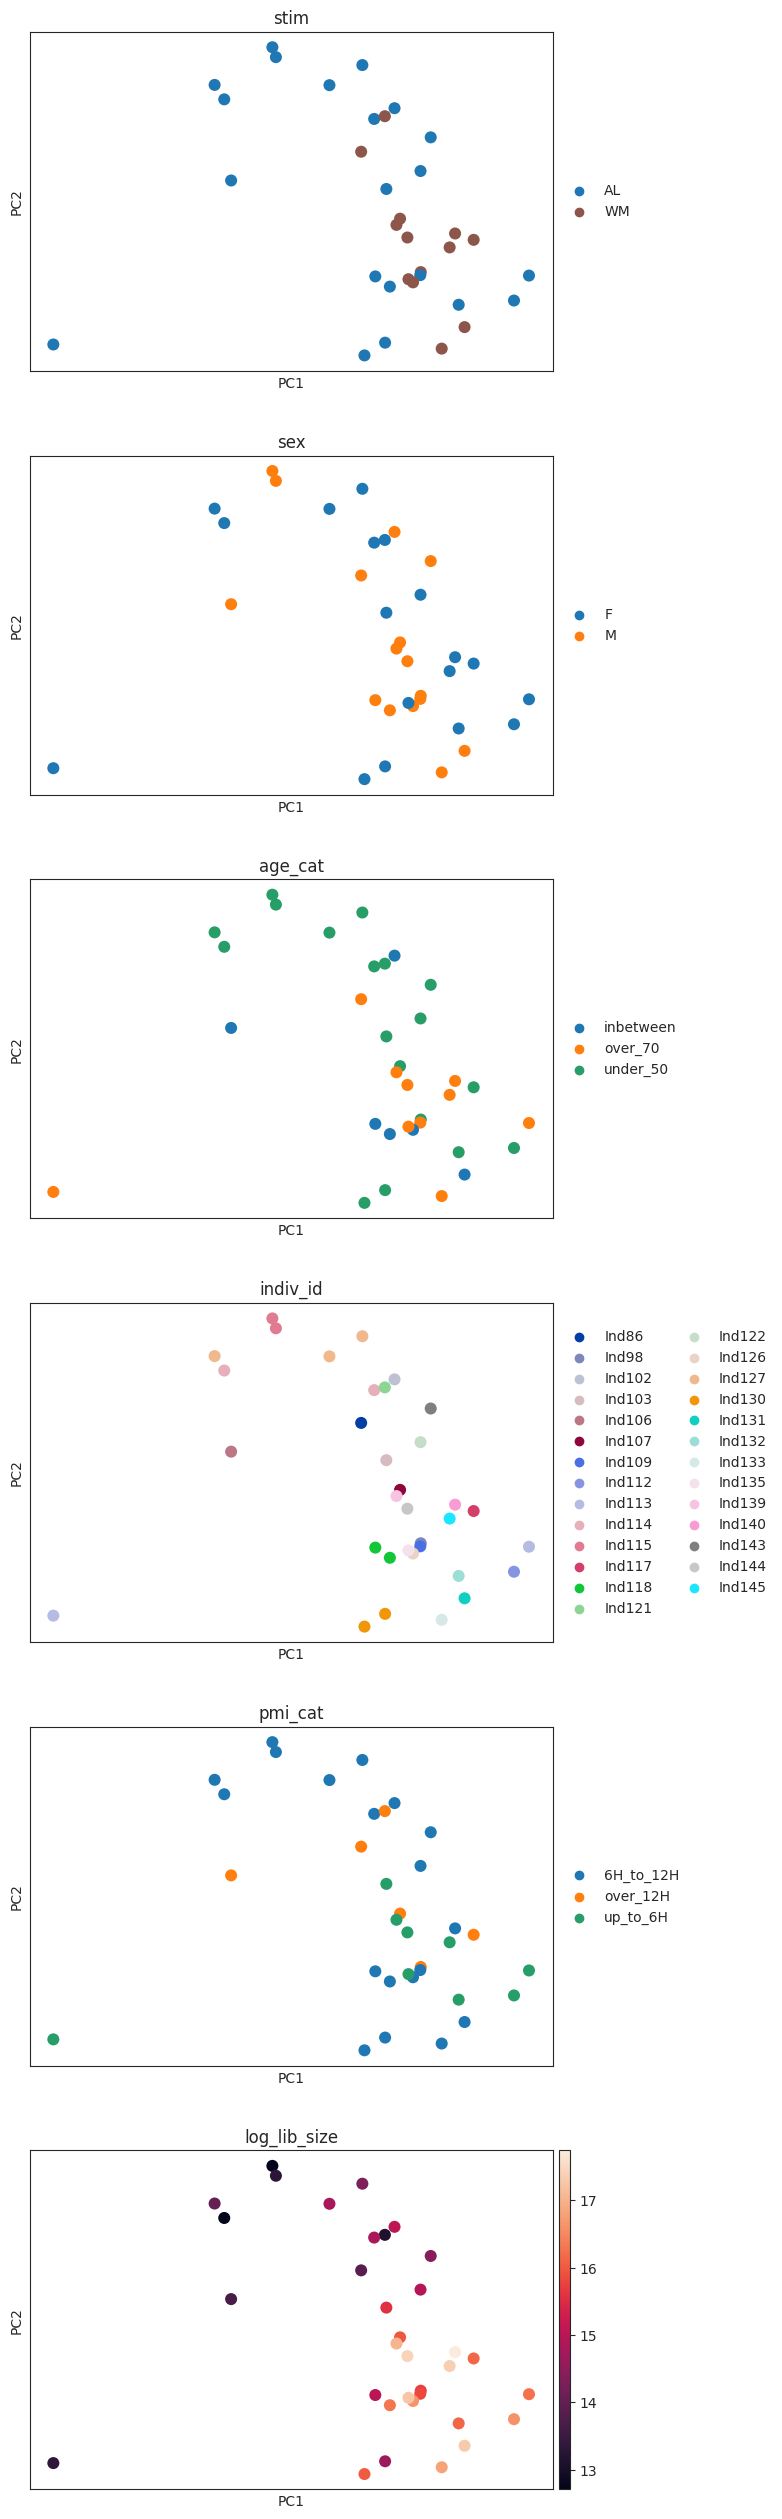

In [18]:
sc.pl.pca(adata_sub, color=["stim", "sex", "age_cat", "indiv_id",
                            "pmi_cat", "log_lib_size"], 
          ncols=1, size=300)

## Set up data

In [19]:
%%R -i adata_sub

# Create the treatments dataframe with samples as a column, not as row names
treatments <- data.frame(
  #Sample = colData(adata_sub)$sample,      # Sample column
  Group = colData(adata_sub)$stim,        # Group (e.g., ctrl or stim)
  Donor = colData(adata_sub)$indiv_id,    # Donor information
  Sex = colData(adata_sub)$sex,           # Sex information
  Age_cat = colData(adata_sub)$age_cat,   # Age category
  Pmi_cat = colData(adata_sub)$pmi_cat   # Post-mortem interval category
)

treatments$Group   <- factor(treatments$Group)
treatments$Donor   <- factor(treatments$Donor)
treatments$Sex     <- factor(treatments$Sex)
treatments$Age_cat <- factor(treatments$Age_cat)
treatments$Pmi_cat <- factor(treatments$Pmi_cat)

# Check the updated dataframe to confirm
head(treatments)

                  Group  Donor Sex   Age_cat   Pmi_cat
Ind86-Sample2_WM     WM  Ind86   M   over_70  over_12H
Ind98-Sample2_WM     WM  Ind98   M  under_50  over_12H
Ind102-Sample1_AL    AL Ind102   M inbetween 6H_to_12H
Ind103-Sample1_AL    AL Ind103   F  under_50  up_to_6H
Ind106-Sample1_AL    AL Ind106   M inbetween  over_12H
Ind107-Sample1_WM    WM Ind107   M  under_50  over_12H


In [20]:
%%R

#Create a DGElist object using the anndata counts in 'X'
x <- DGEList(assay(adata_sub, "X"), group=colData(adata_sub)$stim)

samplenames <- colnames(x$counts)

print("Dimensions before subsetting:")
print(dim(x))

# Check counts per group before filtering
print(table(x$samples$group))

[1] "Dimensions before subsetting:"
[1] 27766    34

AL WM 
21 13 


In [21]:
%%R

# Adjust for batch-- ie publication in the model matrix
design_full <- model.matrix(~0 + Group + Sex + Age_cat + Pmi_cat, data=treatments)

rownames(design_full) <- colnames(x)
colnames(design_full)

[1] "GroupAL"         "GroupWM"         "SexM"            "Age_catover_70" 
[5] "Age_catunder_50" "Pmi_catover_12H" "Pmi_catup_to_6H"


In [22]:
%%R

# More strict removal of genes, tried group, pub and batch
keep.expr <- filterByExpr(x, design_full)
x2 <- x[keep.expr,, keep.lib.sizes=FALSE]
dim(x2)

[1] 18035    34


In [23]:
%%R

## Calc norm factors before to normalize library sizes, then cpm divides counts by lib sizes
#X is before trimming, Y is after trimming, X2 is also trimmed but differently
x2 <- calcNormFactors(x2, method = "TMM")
x2$samples$norm.factors

 [1] 0.9845374 1.0488030 0.8991269 0.9800703 1.0530032 1.0154937 1.0394354
 [8] 1.0256039 1.2743963 1.0513576 0.9110955 1.0635199 0.9717715 0.9873934
[15] 0.9902691 1.0540670 0.9988031 1.0387795 1.0231783 1.0489772 0.9116504
[22] 0.8304263 0.8440103 1.2170657 1.2146423 1.0114954 1.0512461 1.0594034
[29] 0.8175554 0.9410662 0.9618520 0.9739078 0.9029427 0.9615187


In [24]:
%%R 

# Extract the counts matrix from the DGEList object
counts_matrix <- x2$counts
counts_matrix <- as.data.frame(counts_matrix)

# Verify the structure and dimensions of the extracted matrix
print(dim(counts_matrix))  # Check dimensions

[1] 18035    34


In [25]:
%%R
all(rownames(treatments) == colnames(counts_matrix))  # Should return TRUE

[1] TRUE


In [26]:
%%R

wm_samples <- colnames(counts_matrix)[grepl("_WM$", colnames(counts_matrix))]
cat("Number of WM samples:", length(wm_samples), "\n")


all_zero_wm <- character()
for (gene in rownames(counts_matrix)) {
  wm_counts <- counts_matrix[gene, wm_samples]
  
  if (all(wm_counts == 0)) {
    all_zero_wm <- c(all_zero_wm, gene)
  }
}

# Report
cat("Genes with ALL WM counts = 0:\n")
print(all_zero_wm)

Number of WM samples: 13 
Genes with ALL WM counts = 0:
[1] "IGKC"


In [27]:
%%R
counts_matrix["IGKC", "Ind140-Sample1_WM"] <- counts_matrix["IGKC", "Ind140-Sample1_WM"] + 1

In [28]:
%%R

al_samples <- colnames(counts_matrix)[grepl("_AL$", colnames(counts_matrix))]
cat("Number of AL samples:", length(al_samples), "\n")

all_zero_al <- character()
for (gene in rownames(counts_matrix)) {
  al_counts <- counts_matrix[gene, al_samples]
  
  if (all(al_counts == 0)) {
    all_zero_al <- c(all_zero_al, gene)
  }
}

# Report
cat("Genes with ALL AL counts = 0:\n")
print(all_zero_al)

Number of AL samples: 21 
Genes with ALL AL counts = 0:
character(0)


In [29]:
%%R
saveRDS(counts_matrix, file = "./files/counts_matrix_WMvAL.rds")
saveRDS(treatments, file = "./files/treatments_WMvAL.rds")

## Add TMM norm log lib size offset

In [ ]:
%%R

#counts_matrix <- readRDS("./files/counts_matrix_WMvAL.rds")
#treatments <- readRDS("./files/treatments_WMvAL.rds")

In [30]:
%%R
head(treatments)

                  Group  Donor Sex   Age_cat   Pmi_cat
Ind86-Sample2_WM     WM  Ind86   M   over_70  over_12H
Ind98-Sample2_WM     WM  Ind98   M  under_50  over_12H
Ind102-Sample1_AL    AL Ind102   M inbetween 6H_to_12H
Ind103-Sample1_AL    AL Ind103   F  under_50  up_to_6H
Ind106-Sample1_AL    AL Ind106   M inbetween  over_12H
Ind107-Sample1_WM    WM Ind107   M  under_50  over_12H


In [31]:
%%R

#log_lib_size <- log(colSums(counts_matrix))
effective_lib_size <- x2$samples$lib.size * x2$samples$norm.factors
log_lib_size <- log(effective_lib_size)

In [32]:
%%R
all(names(log_lib_size) == rownames(treatments))

[1] TRUE


In [33]:
%%R
treatments$log_lib_size <- log_lib_size
head(treatments)

                  Group  Donor Sex   Age_cat   Pmi_cat log_lib_size
Ind86-Sample2_WM     WM  Ind86   M   over_70  over_12H     13.83557
Ind98-Sample2_WM     WM  Ind98   M  under_50  over_12H     15.76855
Ind102-Sample1_AL    AL Ind102   M inbetween 6H_to_12H     14.95231
Ind103-Sample1_AL    AL Ind103   F  under_50  up_to_6H     15.55124
Ind106-Sample1_AL    AL Ind106   M inbetween  over_12H     13.70778
Ind107-Sample1_WM    WM Ind107   M  under_50  over_12H     15.99321


## Test glmmTMB

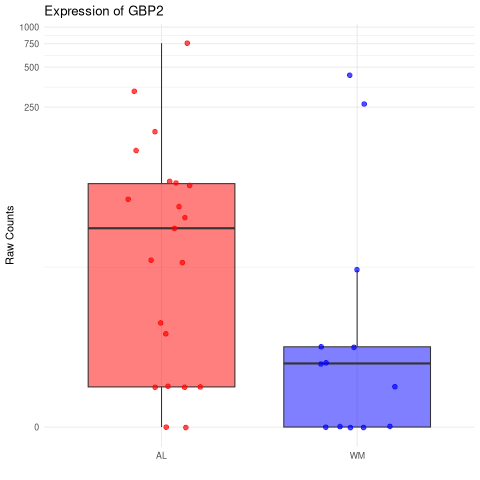

In [34]:
%%R

# Specify your gene
gene_to_plot <- "GBP2"

# Create a data frame with counts and metadata
gene_data <- data.frame(
  expression = as.numeric(counts_matrix[gene_to_plot, ]),
  Group = treatments$Group
)

# Label treatment as WM vs AL (if not already factors)
gene_data$treatment <- factor(gene_data$Group, levels = c("AL", "WM"))

# Inspect
head(gene_data)

# Make the plot
ggplot(gene_data, aes(x = treatment, y = expression, fill = treatment)) +
  geom_boxplot(alpha = 0.5, outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.7, size = 2, aes(color = treatment)) +
  scale_fill_manual(values = c("WM" = "blue", "AL" = "red")) +
  scale_color_manual(values = c("WM" = "blue", "AL" = "red")) +
  labs(
    title = paste("Expression of", gene_to_plot),
    x = "",
    y = "Raw Counts"
  ) +
  theme_minimal() +
  theme(legend.position = "none") +
  scale_y_continuous(trans = "log1p")  # log scale for counts

In [35]:
%%R
# Compute CPM matrix
cpm_matrix <- edgeR::cpm(as.matrix(counts_matrix))

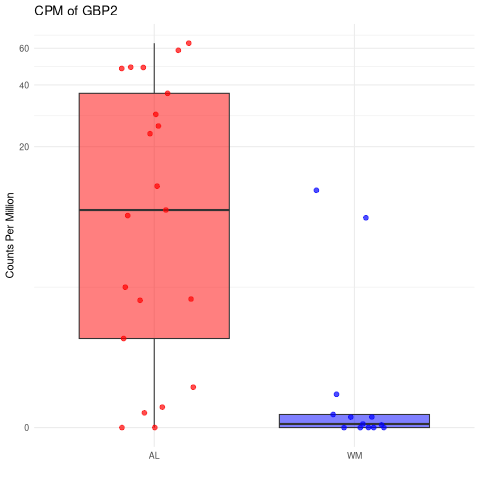

In [36]:
%%R

# Specify your gene
gene_to_plot <- "GBP2"

# Create a data frame with counts and metadata
gene_data <- data.frame(
  cpm = as.numeric(cpm_matrix[gene_to_plot, ]),
  Group = treatments$Group
)

# Label treatment as WM vs AL (if not already factors)
gene_data$treatment <- factor(gene_data$Group, levels = c("AL", "WM"))

# Inspect
head(gene_data)

ggplot(gene_data, aes(x = treatment, y = cpm, fill = treatment)) +
  geom_boxplot(alpha = 0.5, outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.7, size = 2, aes(color = treatment)) +
  scale_fill_manual(values = c("WM" = "blue", "AL" = "red")) +
  scale_color_manual(values = c("WM" = "blue", "AL" = "red")) +
  labs(
    title = paste("CPM of", gene_to_plot),
    x = "",
    y = "Counts Per Million"
  ) +
  theme_minimal() +
  theme(legend.position = "none") +
  scale_y_continuous(trans = "log1p")  # log scale

In [37]:
%%R

# Replace with your gene name
gene_to_test <- "GBP2"  

# Add gene counts to treatments
treatments$counts <- as.numeric(counts_matrix[gene_to_test, ])

# Fit the model
fit <- tryCatch({
  glmmTMB(
    counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor),
    data = treatments,
    family = nbinom2()
  )
}, error = function(e) {
  message("Model failed: ", e$message)
  NULL
})

if (!is.null(fit)) {
  # Extract coefficients
  coef_table <- summary(fit)$coefficients$cond
  
  if ("GroupWM" %in% rownames(coef_table)) {
    logFC   <- coef_table["GroupWM", "Estimate"]
    std_err <- coef_table["GroupWM", "Std. Error"]
    pval    <- coef_table["GroupWM", "Pr(>|z|)"]
    
    cat("Results for gene:", gene_to_test, "\n")
    cat("logFC_WM:", logFC, "\n")
    cat("SE:", std_err, "\n")
    cat("p-value:", pval, "\n")
  } else {
    cat("No GroupWM coefficient found.\n")
  }
} else {
  cat("Model fitting failed.\n")
}

Results for gene: GBP2 
logFC_WM: -2.062784 
SE: 1.265768 
p-value: 0.1031713 


In [38]:
%%R
diagnose(fit)

model looks OK!


In [39]:
%%R
fit_full <- glmmTMB(counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor),
                    data = treatments, family = nbinom2(), offset = log_lib_size)

fit_noRE <- glmmTMB(counts ~ Group + Sex + Age_cat + Pmi_cat,
                    data = treatments, family = nbinom2(), offset = log_lib_size)

anova(fit_noRE, fit_full)

Data: treatments
Models:
fit_noRE: counts ~ Group + Sex + Age_cat + Pmi_cat, zi=~0, disp=~1
fit_full: counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor), zi=~0, disp=~1
         Df    AIC    BIC  logLik deviance Chisq Chi Df Pr(>Chisq)
fit_noRE  8 296.68 308.89 -140.34   280.68                        
fit_full  9 298.68 312.41 -140.34   280.68     0      1          1


In [40]:
%%R
diagnose(fit_full)

Unusually large Z-statistics (|x|>5):

(Intercept) 
  -8.471721 

Large Z-statistics (estimate/std err) suggest a *possible* failure of
the Wald approximation - often also associated with parameters that are
at or near the edge of their range (e.g. random-effects standard
deviations approaching 0).  (Alternately, they may simply represent
very well-estimated parameters; intercepts of non-centered models may
fall in this category.) While the Wald p-values and standard errors
listed in summary() may be unreliable, profile confidence intervals
(see ?confint.glmmTMB) and likelihood ratio test p-values derived by
comparing models (e.g. ?drop1) are probably still OK.  (Note that the
LRT is conservative when the null value is on the boundary, e.g. a
variance or zero-inflation value of 0 (Self and Liang 1987; Stram and
Lee 1994; Goldman and Whelan 2000); in simple cases these p-values are
approximately twice as large as they should be.)




In [41]:
%%R
diagnose(fit_noRE)

Unusually large Z-statistics (|x|>5):

(Intercept) 
  -8.471748 

Large Z-statistics (estimate/std err) suggest a *possible* failure of
the Wald approximation - often also associated with parameters that are
at or near the edge of their range (e.g. random-effects standard
deviations approaching 0).  (Alternately, they may simply represent
very well-estimated parameters; intercepts of non-centered models may
fall in this category.) While the Wald p-values and standard errors
listed in summary() may be unreliable, profile confidence intervals
(see ?confint.glmmTMB) and likelihood ratio test p-values derived by
comparing models (e.g. ?drop1) are probably still OK.  (Note that the
LRT is conservative when the null value is on the boundary, e.g. a
variance or zero-inflation value of 0 (Self and Liang 1987; Stram and
Lee 1994; Goldman and Whelan 2000); in simple cases these p-values are
approximately twice as large as they should be.)




In [42]:
%%R

# Replace with your gene name
gene_to_test <- "GBP2"  

# Add gene counts to treatments
treatments$counts <- as.numeric(counts_matrix[gene_to_test, ])

# Fit the model
fit <- tryCatch({
  glmmTMB(
    counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor),
    data = treatments,
    family = nbinom2(),
    offset = log_lib_size
  )
}, error = function(e) {
  message("Model failed: ", e$message)
  NULL
})

if (!is.null(fit)) {
  # Extract coefficients
  coef_table <- summary(fit)$coefficients$cond
  
  if ("GroupWM" %in% rownames(coef_table)) {
    logFC   <- coef_table["GroupWM", "Estimate"]
    std_err <- coef_table["GroupWM", "Std. Error"]
    pval    <- coef_table["GroupWM", "Pr(>|z|)"]
    
    cat("Results for gene:", gene_to_test, "\n")
    cat("logFC_WM:", logFC, "\n")
    cat("SE:", std_err, "\n")
    cat("p-value:", pval, "\n")
  } else {
    cat("No GroupWM coefficient found.\n")
  }
} else {
  cat("Model fitting failed.\n")
}

Results for gene: GBP2 
logFC_WM: -4.437573 
SE: 1.36768 
p-value: 0.001176165 


In [43]:
%%R
diagnose(fit)

Unusually large Z-statistics (|x|>5):

(Intercept) 
  -8.471721 

Large Z-statistics (estimate/std err) suggest a *possible* failure of
the Wald approximation - often also associated with parameters that are
at or near the edge of their range (e.g. random-effects standard
deviations approaching 0).  (Alternately, they may simply represent
very well-estimated parameters; intercepts of non-centered models may
fall in this category.) While the Wald p-values and standard errors
listed in summary() may be unreliable, profile confidence intervals
(see ?confint.glmmTMB) and likelihood ratio test p-values derived by
comparing models (e.g. ?drop1) are probably still OK.  (Note that the
LRT is conservative when the null value is on the boundary, e.g. a
variance or zero-inflation value of 0 (Self and Liang 1987; Stram and
Lee 1994; Goldman and Whelan 2000); in simple cases these p-values are
approximately twice as large as they should be.)




## Simpler models to consider?

In [45]:
%%R
# Model with only Group
m1 <- glm.nb(counts ~ Group + offset(log_lib_size), data = treatments)

# Add Sex
m2 <- glm.nb(counts ~ Group + Sex + offset(log_lib_size), data = treatments)

# Add Age_cat
m3 <- glm.nb(counts ~ Group + Sex + Age_cat + offset(log_lib_size), data = treatments)

# Add Pmi_cat
m4 <- glm.nb(counts ~ Group + Sex + Age_cat + Pmi_cat + offset(log_lib_size), data = treatments)

# Compare AIC and convergence
AIC(m1, m2, m3, m4)

   df      AIC
m1  3 292.7849
m2  4 294.5110
m3  6 294.4146
m4  8 297.4010


In addition: There were 27 warnings (use warnings() to see them)


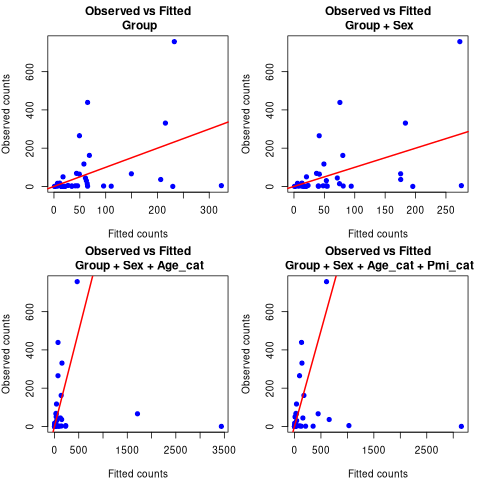

In [46]:
%%R
# List of models
models <- list(m1, m2, m3, m4)
model_names <- c("Group", "Group + Sex", "Group + Sex + Age_cat", "Group + Sex + Age_cat + Pmi_cat")

# Set up 2x2 plotting grid
par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

for (i in seq_along(models)) {
  fitted_vals <- fitted(models[[i]])
  
  plot(
    fitted_vals,
    treatments$counts,
    main = paste("Observed vs Fitted\n", model_names[i]),
    xlab = "Fitted counts",
    ylab = "Observed counts",
    pch = 19,
    col = "blue"
  )
  
  abline(0, 1, col = "red", lwd = 2)  # Reference line y = x
}

# Reset plotting layout
par(mfrow = c(1,1))

## Run full code...

In [47]:
%%R

# Start time
start_time <- Sys.time()
cat("Started GLMM fitting at:", start_time, "\n")

# Number of cores
n_cores <- 12

# Genes to test
genes_to_test <- rownames(counts_matrix)
total_genes <- length(genes_to_test)

# Fit function
fit_gene <- function(gene) {
  if (!(gene %in% rownames(counts_matrix))) return(NULL)

  # Counts for this gene
  treatments$counts <- as.numeric(counts_matrix[gene, ])

  fit <- tryCatch({
    glmmTMB(
      counts ~ Group + Sex + Age_cat + Pmi_cat + (1 | Donor),
      data = treatments,
      family = nbinom2(),
      offset = log_lib_size
    )
  }, error = function(e) return(list(error = e$message)))

  # Handle errors
  if (is.list(fit) && "error" %in% names(fit)) {
    return(data.frame(
      gene = gene,
      logFC_WM = NA,
      se = NA,
      pvalue = NA,
      convergence = NA,
      pdHess = NA,
      logLik = NA,
      AIC = NA,
      error = fit$error,
      stringsAsFactors = FALSE
    ))
  }

  # Get coefficient table
  coef_table <- summary(fit)$coefficients$cond

  # If GroupWM not found
  if (!("GroupWM" %in% rownames(coef_table))) {
    return(data.frame(
      gene = gene,
      logFC_WM = NA,
      se = NA,
      pvalue = NA,
      convergence = fit$fit$convergence,
      pdHess = fit$sdr$pdHess,
      logLik = as.numeric(logLik(fit)),
      AIC = AIC(fit),
      error = "No GroupWM term",
      stringsAsFactors = FALSE
    ))
  }

  # Otherwise, record the metrics
  return(data.frame(
    gene = gene,
    logFC_WM = coef_table["GroupWM", "Estimate"],
    se = coef_table["GroupWM", "Std. Error"],
    pvalue = coef_table["GroupWM", "Pr(>|z|)"],
    convergence = fit$fit$convergence,
    pdHess = fit$sdr$pdHess,
    logLik = as.numeric(logLik(fit)),
    AIC = AIC(fit),
    error = NA,
    stringsAsFactors = FALSE
  ))
}

# Run in parallel
results_list <- pbmclapply(
  genes_to_test,
  fit_gene,
  mc.cores = n_cores
)

# Combine results
results_df <- do.call(rbind, Filter(Negate(is.null), results_list))

# Adjust p-values
results_df$FDR <- p.adjust(results_df$pvalue, method = "BH")
results_df <- results_df[order(results_df$FDR), ]

# Save to CSV for inspection
write.csv(results_df, "./files/GLMM_full_results_with_quality_ALvWM.csv", row.names = FALSE)

# Timing
end_time <- Sys.time()
cat("Finished at:", end_time, "\n")
cat("Runtime:", difftime(end_time, start_time, units = "mins"), "\n")

Started GLMM fitting at: 1752407610 
  |=======================================================| 100%, Elapsed 16:52
Finished at: 1752408624 
Runtime: 16.89547 


In [48]:
%%R
dim(results_df)

[1] 18035    10


In [49]:
%%R
head(results_df)

        gene   logFC_WM         se       pvalue convergence pdHess     logLik
4040  FGFRL1  1.1738705 0.14055174 6.718800e-17           0   TRUE -111.18380
14560 WRAP53 -0.6017076 0.07615584 2.766644e-15           0   TRUE -111.52958
8035    SGCZ -3.2753774 0.42563905 1.412734e-14           0   TRUE -241.34958
4409  GPRIN3 -3.9587244 0.52002134 2.685965e-14           0   TRUE  -89.73582
8998  PTPDC1  0.6086374 0.08086415 5.205239e-14           0   TRUE -191.02072
8053    PSD3  0.6931467 0.09745717 1.141073e-12           0   TRUE -254.17709
           AIC error          FDR
4040  240.3676    NA 1.210526e-12
14560 241.0592    NA 2.492331e-11
8035  500.6992    NA 8.484408e-11
4409  197.4716    NA 1.209826e-10
8998  400.0414    NA 1.875656e-10
8053  526.3542    NA 3.426453e-09


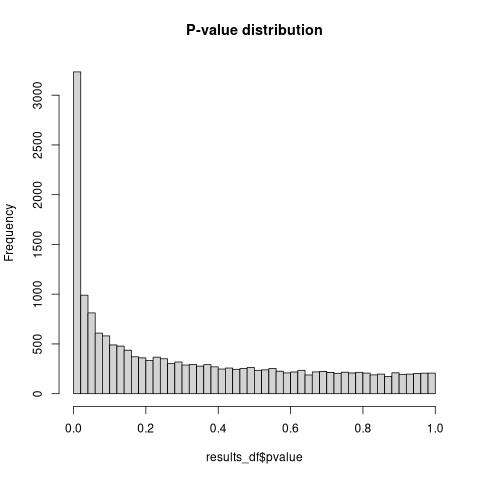

In [50]:
%%R
hist(results_df$pvalue, breaks = 50, main = "P-value distribution")

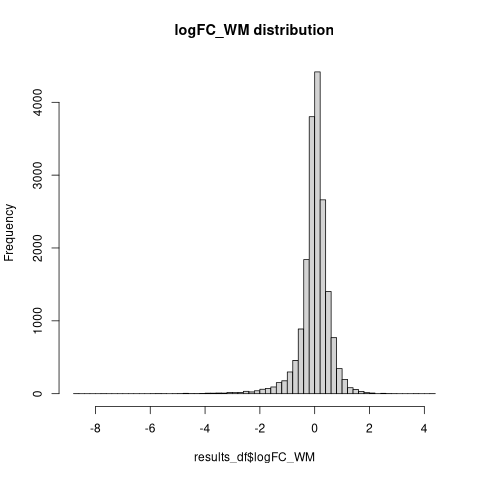

In [51]:
%%R
hist(results_df$logFC_WM, breaks = 50, main = "logFC_WM distribution")

In [52]:
%%R
table(results_df$convergence, results_df$pdHess)

   
    FALSE  TRUE
  0   443 14958
  1   741  1893


In [53]:
%%R

# Create a status flag column
results_df$status <- with(results_df, ifelse(
  convergence == 0 & pdHess == TRUE,
  "OK",
  "Check"
))

# Subset to keep only safe results
results_df_clean <- subset(results_df, status == "OK")

# Inspect how many genes remain
cat("Number of safe models:", nrow(results_df_clean), "\n")

# Write to CSV
write.csv(results_df_clean, "./files/GLMM_full_results_with_quality_ALvWM_cleaned.csv", row.names = FALSE)

Number of safe models: 14958 


In [54]:
%%R
head(results_df_clean)

        gene   logFC_WM         se       pvalue convergence pdHess     logLik
4040  FGFRL1  1.1738705 0.14055174 6.718800e-17           0   TRUE -111.18380
14560 WRAP53 -0.6017076 0.07615584 2.766644e-15           0   TRUE -111.52958
8035    SGCZ -3.2753774 0.42563905 1.412734e-14           0   TRUE -241.34958
4409  GPRIN3 -3.9587244 0.52002134 2.685965e-14           0   TRUE  -89.73582
8998  PTPDC1  0.6086374 0.08086415 5.205239e-14           0   TRUE -191.02072
8053    PSD3  0.6931467 0.09745717 1.141073e-12           0   TRUE -254.17709
           AIC error          FDR status
4040  240.3676    NA 1.210526e-12     OK
14560 241.0592    NA 2.492331e-11     OK
8035  500.6992    NA 8.484408e-11     OK
4409  197.4716    NA 1.209826e-10     OK
8998  400.0414    NA 1.875656e-10     OK
8053  526.3542    NA 3.426453e-09     OK


In [55]:
%%R
# Subset for significant and strong effect size
sig_results <- subset(
  results_df_clean,
  FDR < 0.05 & abs(logFC_WM) >= 0.585
)

# See how many
cat("Number of significant genes:", nrow(sig_results), "\n")

# View top rows
head(sig_results)

Number of significant genes: 852 
        gene   logFC_WM         se       pvalue convergence pdHess     logLik
4040  FGFRL1  1.1738705 0.14055174 6.718800e-17           0   TRUE -111.18380
14560 WRAP53 -0.6017076 0.07615584 2.766644e-15           0   TRUE -111.52958
8035    SGCZ -3.2753774 0.42563905 1.412734e-14           0   TRUE -241.34958
4409  GPRIN3 -3.9587244 0.52002134 2.685965e-14           0   TRUE  -89.73582
8998  PTPDC1  0.6086374 0.08086415 5.205239e-14           0   TRUE -191.02072
8053    PSD3  0.6931467 0.09745717 1.141073e-12           0   TRUE -254.17709
           AIC error          FDR status
4040  240.3676    NA 1.210526e-12     OK
14560 241.0592    NA 2.492331e-11     OK
8035  500.6992    NA 8.484408e-11     OK
4409  197.4716    NA 1.209826e-10     OK
8998  400.0414    NA 1.875656e-10     OK
8053  526.3542    NA 3.426453e-09     OK


In [56]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- results_df_clean[results_df_clean$FDR < 0.05 & results_df_clean$logFC_WM >= 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_WM, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 411
            gene logFC_WM        se       pvalue convergence pdHess     logLik
12926     AHNAK2 2.597480 0.8078429 1.302953e-03           0   TRUE  -97.19964
842   AC114485.1 2.467304 0.5819377 2.237107e-05           0   TRUE -168.90979
7669   LINC00891 2.164087 0.3413514 2.301198e-10           0   TRUE -109.18874
2008       EPAS1 2.125811 0.6923901 2.138796e-03           0   TRUE  -70.71847
1860        POMC 2.078927 0.7397869 4.951523e-03           0   TRUE  -66.43594
1471       RAB7B 2.075214 0.4138116 5.306732e-07           0   TRUE -137.09835
           AIC error          FDR status
12926 212.3993    NA 2.034337e-02     OK
842   355.8196    NA 1.370951e-03     OK
7669  236.3775    NA 3.189284e-07     OK
2008  159.4369    NA 2.792389e-02     OK
1860  150.8719    NA 4.773219e-02     OK
1471  292.1967    NA 1.062349e-04     OK


In [57]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- results_df_clean[results_df_clean$FDR < 0.05 & results_df_clean$logFC_WM <= -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_WM, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 443
        gene  logFC_WM       se       pvalue convergence pdHess    logLik
17779 MAPK11 -5.772282 1.657699 4.974899e-04           0   TRUE -37.50570
7067     VGF -5.640046 1.460401 1.124704e-04           0   TRUE -51.91877
8601    LY6H -5.529655 1.383451 6.414998e-05           0   TRUE -48.02741
9337   EGFL7 -5.091464 1.604086 1.503228e-03           0   TRUE -36.70474
2945   ARL4C -4.737367 1.631160 3.680842e-03           0   TRUE -68.95552
2872   PTPRN -4.608971 1.128224 4.404692e-05           0   TRUE -50.55652
            AIC error         FDR status
17779  93.01139    NA 0.011045214     OK
7067  121.83753    NA 0.004044669     OK
8601  114.05483    NA 0.002785037     OK
9337   91.40949    NA 0.022073079     OK
2945  155.91103    NA 0.039218057     OK
2872  119.11305    NA 0.002185720     OK


## Simplify the glmm

In [58]:
%%R

# Start time
start_time <- Sys.time()
cat("Started GLMM fitting at:", start_time, "\n")

# Number of cores
n_cores <- 12

# Genes to test
genes_to_test <- rownames(counts_matrix)
total_genes <- length(genes_to_test)

# Fit function
fit_gene <- function(gene) {
  if (!(gene %in% rownames(counts_matrix))) return(NULL)

  # Counts for this gene
  treatments$counts <- as.numeric(counts_matrix[gene, ])

  fit <- tryCatch({
    glmmTMB(
      counts ~ Group + (1 | Donor),
      data = treatments,
      family = nbinom2(),
      offset = log_lib_size
    )
  }, error = function(e) return(list(error = e$message)))

  # Handle errors
  if (is.list(fit) && "error" %in% names(fit)) {
    return(data.frame(
      gene = gene,
      logFC_WM = NA,
      se = NA,
      pvalue = NA,
      convergence = NA,
      pdHess = NA,
      logLik = NA,
      AIC = NA,
      error = fit$error,
      stringsAsFactors = FALSE
    ))
  }

  # Get coefficient table
  coef_table <- summary(fit)$coefficients$cond

  # If GroupWM not found
  if (!("GroupWM" %in% rownames(coef_table))) {
    return(data.frame(
      gene = gene,
      logFC_WM = NA,
      se = NA,
      pvalue = NA,
      convergence = fit$fit$convergence,
      pdHess = fit$sdr$pdHess,
      logLik = as.numeric(logLik(fit)),
      AIC = AIC(fit),
      error = "No GroupWM term",
      stringsAsFactors = FALSE
    ))
  }

  # Otherwise, record the metrics
  return(data.frame(
    gene = gene,
    logFC_WM = coef_table["GroupWM", "Estimate"],
    se = coef_table["GroupWM", "Std. Error"],
    pvalue = coef_table["GroupWM", "Pr(>|z|)"],
    convergence = fit$fit$convergence,
    pdHess = fit$sdr$pdHess,
    logLik = as.numeric(logLik(fit)),
    AIC = AIC(fit),
    error = NA,
    stringsAsFactors = FALSE
  ))
}

# Run in parallel
results_list <- pbmclapply(
  genes_to_test,
  fit_gene,
  mc.cores = n_cores
)

# Combine results
results_df <- do.call(rbind, Filter(Negate(is.null), results_list))

# Adjust p-values
results_df$FDR <- p.adjust(results_df$pvalue, method = "BH")
results_df <- results_df[order(results_df$FDR), ]

# Save to CSV for inspection
write.csv(results_df, "./files/GLMM_results_simplified_ALvWM_all.csv", row.names = FALSE)

# Timing
end_time <- Sys.time()
cat("Finished at:", end_time, "\n")
cat("Runtime:", difftime(end_time, start_time, units = "mins"), "\n")

Started GLMM fitting at: 1752408624 
  |=======================================================| 100%, Elapsed 15:49
Finished at: 1752409575 
Runtime: 15.83728 


In [59]:
%%R
dim(results_df)

[1] 18035    10


In [60]:
%%R
head(results_df)

         gene   logFC_WM         se       pvalue convergence pdHess    logLik
8035     SGCZ -2.9870366 0.33266358 2.728633e-19           0   TRUE -243.1211
9580    LUZP2 -2.0137818 0.22747779 8.546335e-19           0   TRUE -213.4981
2094    EHBP1 -0.5573346 0.07669894 3.688574e-13           0   TRUE -220.9854
1708    COX20  0.2575471 0.03607742 9.419408e-13           1  FALSE        NA
347   COL16A1  1.0898297 0.15381990 1.389416e-12           0   TRUE -214.9743
15591 ST8SIA5 -1.4372995 0.20698629 3.813241e-12           0   TRUE -205.4151
           AIC error          FDR
8035  494.2422    NA 4.918908e-15
9580  434.9963    NA 7.703239e-15
2094  449.9708    NA 2.216464e-09
1708        NA    NA 4.245092e-09
347   437.9486    NA 5.009401e-09
15591 418.8303    NA 1.145688e-08


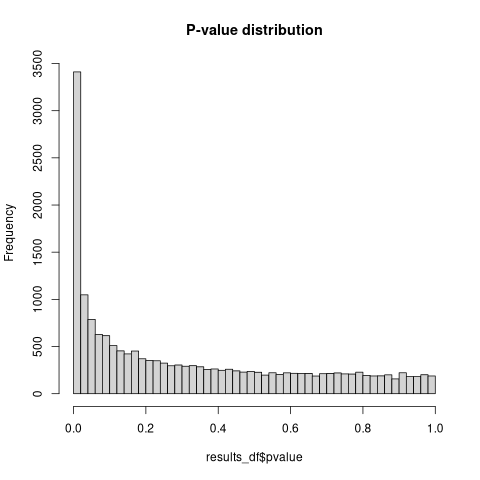

In [61]:
%%R
hist(results_df$pvalue, breaks = 50, main = "P-value distribution")

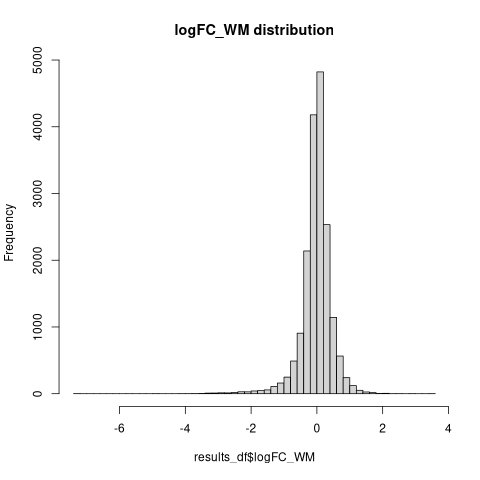

In [62]:
%%R
hist(results_df$logFC_WM, breaks = 50, main = "logFC_WM distribution")

In [63]:
%%R
table(results_df$convergence, results_df$pdHess)

   
    FALSE  TRUE
  0   471 15204
  1   644  1716


In [64]:
%%R

# Create a status flag column
results_df$status <- with(results_df, ifelse(
  convergence == 0 & pdHess == TRUE,
  "OK",
  "Check"
))

# Subset to keep only safe results
results_df_clean <- subset(results_df, status == "OK")

# Inspect how many genes remain
cat("Number of safe models:", nrow(results_df_clean), "\n")

# Write to CSV
write.csv(results_df_clean, "./files/GLMM_results_simplified_with_quality_ALvWM_cleaned.csv", row.names = FALSE)

Number of safe models: 15204 


In [65]:
%%R
head(results_df_clean)

         gene   logFC_WM         se       pvalue convergence pdHess    logLik
8035     SGCZ -2.9870366 0.33266358 2.728633e-19           0   TRUE -243.1211
9580    LUZP2 -2.0137818 0.22747779 8.546335e-19           0   TRUE -213.4981
2094    EHBP1 -0.5573346 0.07669894 3.688574e-13           0   TRUE -220.9854
347   COL16A1  1.0898297 0.15381990 1.389416e-12           0   TRUE -214.9743
15591 ST8SIA5 -1.4372995 0.20698629 3.813241e-12           0   TRUE -205.4151
7187     GRM8 -1.9926154 0.29022188 6.610370e-12           0   TRUE -192.0251
           AIC error          FDR status
8035  494.2422    NA 4.918908e-15     OK
9580  434.9963    NA 7.703239e-15     OK
2094  449.9708    NA 2.216464e-09     OK
347   437.9486    NA 5.009401e-09     OK
15591 418.8303    NA 1.145688e-08     OK
7187  392.0503    NA 1.702359e-08     OK


In [66]:
%%R
# Subset for significant and strong effect size
sig_results <- subset(
  results_df_clean,
  FDR < 0.05 & abs(logFC_WM) >= 0.585
)

# See how many
cat("Number of significant genes:", nrow(sig_results), "\n")

# View top rows
head(sig_results)

Number of significant genes: 774 
         gene   logFC_WM         se       pvalue convergence pdHess    logLik
8035     SGCZ -2.9870366 0.33266358 2.728633e-19           0   TRUE -243.1211
9580    LUZP2 -2.0137818 0.22747779 8.546335e-19           0   TRUE -213.4981
347   COL16A1  1.0898297 0.15381990 1.389416e-12           0   TRUE -214.9743
15591 ST8SIA5 -1.4372995 0.20698629 3.813241e-12           0   TRUE -205.4151
7187     GRM8 -1.9926154 0.29022188 6.610370e-12           0   TRUE -192.0251
6485    SYNJ2  0.6312264 0.09304737 1.169538e-11           0   TRUE -276.3757
           AIC error          FDR status
8035  494.2422    NA 4.918908e-15     OK
9580  434.9963    NA 7.703239e-15     OK
347   437.9486    NA 5.009401e-09     OK
15591 418.8303    NA 1.145688e-08     OK
7187  392.0503    NA 1.702359e-08     OK
6485  560.7513    NA 2.635407e-08     OK


In [67]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- results_df_clean[results_df_clean$FDR < 0.05 & results_df_clean$logFC_WM >= 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_WM, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 358
            gene logFC_WM        se       pvalue convergence pdHess     logLik
12926     AHNAK2 2.965703 0.6291202 2.428431e-06           0   TRUE  -99.10349
6054       VEGFA 2.569310 0.8790685 3.469396e-03           0   TRUE -100.46065
2008       EPAS1 2.161845 0.4509185 1.632322e-06           0   TRUE  -71.96584
15717 AC104423.1 2.086842 0.4121046 4.108393e-07           0   TRUE  -82.65283
9548       ABCC8 2.008917 0.4083744 8.685344e-07           0   TRUE -152.66670
4052       FGFR3 1.971949 0.6831108 3.892826e-03           0   TRUE  -63.88405
           AIC error          FDR status
12926 206.2070    NA 0.0002379202     OK
6054  208.9213    NA 0.0354752178     OK
2008  151.9317    NA 0.0001762028     OK
15717 173.3057    NA 0.0000726098     OK
9548  313.3334    NA 0.0001168438     OK
4052  135.7681    NA 0.0384315289     OK


In [68]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- results_df_clean[results_df_clean$FDR < 0.05 & results_df_clean$logFC_WM <= -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_WM, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 416
           gene  logFC_WM        se       pvalue convergence pdHess    logLik
2262       IGKC -7.266595 1.5132859 1.571943e-06           0   TRUE -53.86119
8072     PHYHIP -4.955524 1.3387784 2.143060e-04           0   TRUE -39.45919
8097       NEFL -4.105510 1.1963486 5.998099e-04           0   TRUE -48.62564
10291      NRGN -3.933628 1.3104696 2.684826e-03           0   TRUE -44.22634
12424 LINC01551 -3.668051 1.1528428 1.463912e-03           0   TRUE -37.73396
2872      PTPRN -3.658546 0.8969587 4.526216e-05           0   TRUE -53.76886
            AIC error          FDR status
2262  115.72238    NA 0.0001727891     OK
8072   86.91837    NA 0.0057318901     OK
8097  105.25128    NA 0.0111882663     OK
10291  96.45268    NA 0.0299285748     OK
12424  83.46793    NA 0.0199169394     OK
2872  115.53772    NA 0.0019520119     OK


## Try with simple nb model

In [69]:
%%R

# Number of cores
n_cores <- 12

# Genes to test
genes_to_test <- rownames(counts_matrix)
total_genes <- length(genes_to_test)

# Fit function for m1 model
fit_gene_m1 <- function(gene) {
  if (!(gene %in% rownames(counts_matrix))) return(NULL)

  # Counts for this gene
  treatments$counts <- as.numeric(counts_matrix[gene, ])

  fit <- tryCatch({
    glm.nb(
      counts ~ Group + offset(log_lib_size),
      data = treatments
    )
  }, error = function(e) return(list(error = e$message)))

  # Handle errors
  if (is.list(fit) && "error" %in% names(fit)) {
    return(data.frame(
      gene = gene,
      logFC_WM = NA,
      se = NA,
      pvalue = NA,
      convergence = NA,  # glm.nb doesn't give explicit convergence like glmmTMB
      logLik = NA,
      AIC = NA,
      error = fit$error,
      stringsAsFactors = FALSE
    ))
  }

  # Get coefficient table
  coef_table <- summary(fit)$coefficients

  # If GroupWM not found
  if (!("GroupWM" %in% rownames(coef_table))) {
    return(data.frame(
      gene = gene,
      logFC_WM = NA,
      se = NA,
      pvalue = NA,
      convergence = NA,
      logLik = as.numeric(logLik(fit)),
      AIC = AIC(fit),
      error = "No GroupWM term",
      stringsAsFactors = FALSE
    ))
  }

  # Otherwise, record the metrics
  return(data.frame(
    gene = gene,
    logFC_WM = coef_table["GroupWM", "Estimate"],
    se = coef_table["GroupWM", "Std. Error"],
    pvalue = coef_table["GroupWM", "Pr(>|z|)"],
    convergence = NA,
    logLik = as.numeric(logLik(fit)),
    AIC = AIC(fit),
    error = NA,
    stringsAsFactors = FALSE
  ))
}

# Run in parallel
results_list <- pbmclapply(
  genes_to_test,
  fit_gene_m1,
  mc.cores = n_cores
)

# Combine results
results_df <- do.call(rbind, Filter(Negate(is.null), results_list))

# Adjust p-values
results_df$FDR <- p.adjust(results_df$pvalue, method = "BH")
results_df <- results_df[order(results_df$FDR), ]

# Save to CSV for inspection
write.csv(results_df, "./files/GLM_nb_results_Group_only_ALvsWM.csv", row.names = FALSE)

  |=============                                              |  22%, ETA 00:14

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



  |===========================                                |  45%, ETA 00:09

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



  |========================================                   |  68%, ETA 00:05

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



  |======================================================     |  91%, ETA 00:01

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



  |=======================================================| 100%, Elapsed 00:17


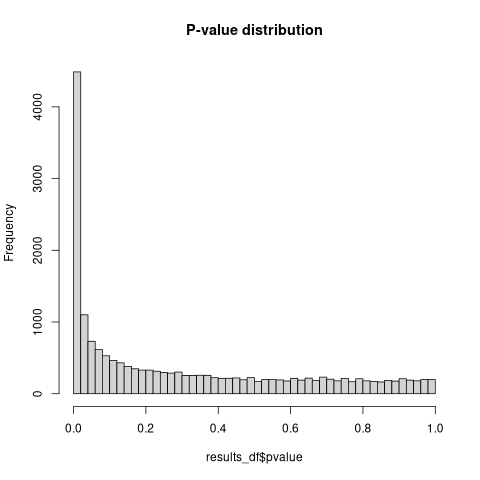

In [70]:
%%R
hist(results_df$pvalue, breaks = 50, main = "P-value distribution")

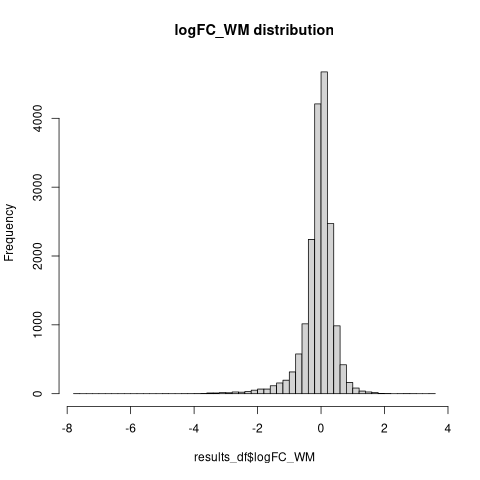

In [71]:
%%R
hist(results_df$logFC_WM, breaks = 50, main = "logFC_WM distribution")

In [72]:
%%R
# Subset for significant and strong effect size
sig_results <- subset(
  results_df,
  FDR <= 0.05 & abs(logFC_WM) >= 0.585
)

# See how many
cat("Number of significant genes:", nrow(sig_results), "\n")

# View top rows
head(sig_results)

Number of significant genes: 1614 
        gene   logFC_WM          se        pvalue convergence     logLik
5273   CHSY3 -1.0121236 0.021968248  0.000000e+00          NA  -1343.432
17390    UTY  0.7208730 0.009595011  0.000000e+00          NA -58439.340
17394 TTTY14  0.7391643 0.015235578  0.000000e+00          NA -23554.335
17396  KDM5D  1.1752211 0.025812359  0.000000e+00          NA -10579.136
5140    GLRX -0.9251737 0.026717644 9.637659e-263          NA  -1410.015
6524  PDE10A  0.7573548 0.023359113 1.333978e-230          NA  -1999.166
             AIC error           FDR
5273    2692.864    NA  0.000000e+00
17390 116884.680    NA  0.000000e+00
17394  47114.670    NA  0.000000e+00
17396  21164.271    NA  0.000000e+00
5140    2826.029    NA 1.931280e-259
6524    4004.332    NA 2.405829e-227


In [73]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- results_df[results_df$FDR < 0.05 & results_df$logFC_WM >= 0.585, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC_WM, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 506
        gene logFC_WM        se       pvalue convergence     logLik      AIC
9051   NR4A3 3.436529 1.0047078 6.252299e-04          NA  -74.19797 154.3959
12926 AHNAK2 2.965704 0.6200400 1.726243e-06          NA  -99.10349 204.2070
6054   VEGFA 2.689368 0.6718055 6.249282e-05          NA -101.73783 209.4757
15879    ID1 2.626111 0.8761885 2.724734e-03          NA  -60.76968 127.5394
6677     NPY 2.491443 0.8415405 3.070658e-03          NA  -77.50439 161.0088
2008   EPAS1 2.161846 0.4524913 1.773544e-06          NA  -71.96584 149.9317
      error          FDR
9051     NA 6.625160e-03
12926    NA 7.593362e-05
6054     NA 1.177596e-03
15879    NA 1.921713e-02
6677     NA 2.097701e-02
2008     NA 7.688908e-05


In [74]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- results_df[results_df$FDR < 0.05 & results_df$logFC_WM <= -0.585, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC_WM, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 1108
        gene  logFC_WM        se       pvalue convergence      logLik
2262    IGKC -7.656422 1.0006157 1.983221e-14          NA -1137.23852
8072  PHYHIP -4.955549 1.3788112 3.255480e-04          NA   -39.45919
9914   CLCF1 -4.388860 1.1337074 1.082804e-04          NA   -48.06157
8097    NEFL -4.105479 1.2237059 7.937776e-04          NA   -48.62564
8601    LY6H -3.978199 0.9510138 2.875435e-05          NA   -52.45989
10291   NRGN -3.933642 1.3401487 3.333022e-03          NA   -44.22632
             AIC error          FDR
2262  2280.47704    NA 4.833430e-12
8072    84.91837    NA 4.007684e-03
9914   102.12314    NA 1.819979e-03
8097   103.25128    NA 7.874466e-03
8601   110.91978    NA 6.787758e-04
10291   94.45265    NA 2.227738e-02


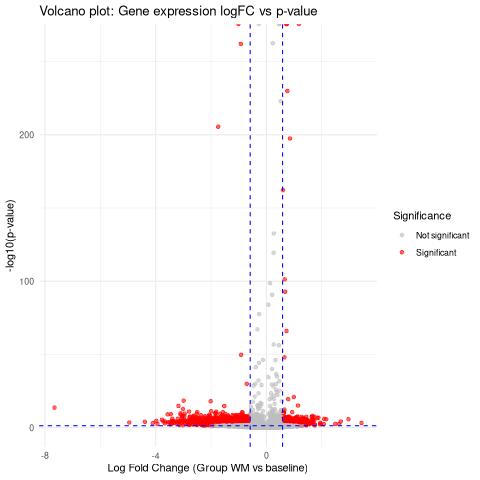

In [75]:
%%R

# Add a -log10(pvalue) column for plotting
results_df$negLogP <- -log10(results_df$pvalue)

# Define significance thresholds
logFC_cutoff <- 0.585       # You can adjust this
pvalue_cutoff <- 0.05

# Add a column for significance status
results_df$Significance <- "Not significant"
results_df$Significance[results_df$pvalue < pvalue_cutoff & abs(results_df$logFC_WM) >= logFC_cutoff] <- "Significant"

# Plot
ggplot(results_df, aes(x = logFC_WM, y = negLogP, color = Significance)) +
  geom_point(alpha = 0.6) +
  scale_color_manual(values = c("gray", "red")) +
  geom_vline(xintercept = c(-logFC_cutoff, logFC_cutoff), linetype = "dashed", color = "blue") +
  geom_hline(yintercept = -log10(pvalue_cutoff), linetype = "dashed", color = "blue") +
  labs(title = "Volcano plot: Gene expression logFC vs p-value",
       x = "Log Fold Change (Group WM vs baseline)",
       y = "-log10(p-value)") +
  theme_minimal()